In [43]:
%cd /home/dani/projects/neuroscience

/home/dani/projects/neuroscience


In [44]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

In [45]:
data = []
for i in range(30):
    data.append(np.load(f"data_processed/adhd/timeseries_{i}.npy"))

In [46]:
class TimeSeriesDataset(Dataset):
    """Dataset class for time series data with residual learning."""
    
    def __init__(self, data):
        """
        Args:
            data: numpy array of shape (n_t, n_x) where n_t is time steps, n_x is features
        """
        self.data = [torch.FloatTensor(data[i]) for i in range(len(data))]
        self.n_patients = len(self.data)
        
    def __len__(self):
        return self.n_patients  # We need pairs (x_t, x_{t+1})
    
    def __getitem__(self, idx):
        n_t = self.data[idx].shape[0]
        idt = np.random.randint(0, n_t-1)
        
        x_t = self.data[idx][idt]
        x_t_plus_1 = self.data[idx][idt+1]
        return x_t, x_t_plus_1
    
class ResidualNN(nn.Module):
    """1-layer neural network for residual learning: x_{t+1} = x_t + f_θ(x_t)"""
    
    def __init__(self, input_dim, hidden_dim=200, activation='relu'):
        super(ResidualNN, self).__init__()
            
        # Single layer network f_θ(x_t)
        self.f_theta = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, input_dim)  # Output same size as input for residual
        )
    
    def forward(self, x_t):
        # Residual connection: x_{t+1} = x_t + f_θ(x_t)
        residual = self.f_theta(x_t)
        x_t_plus_1 = x_t + residual
        return x_t_plus_1

In [47]:
class ResidualNNTrainer:
    """Trainer class for the residual neural network."""
    
    def __init__(self, model, device='cpu'):
        self.model = model.to(device)
        self.device = device
        self.train_losses = []
        self.val_losses = []
        
    def train(self, train_loader, val_loader=None, epochs=500, lr=0.01, 
              criterion=nn.MSELoss(), optimizer_class=optim.Adam):
        """
        Train the model.
        
        Args:
            train_loader: DataLoader for training data
            val_loader: DataLoader for validation data (optional)
            epochs: Number of training epochs
            lr: Learning rate
            criterion: Loss function
            optimizer_class: Optimizer class
        """
        optimizer = optimizer_class(self.model.parameters(), lr=lr)
        
        for epoch in range(epochs):
            # Training
            self.model.train()
            train_loss = 0.0
            
            for x_t, x_t_plus_1 in train_loader:
                x_t = x_t.to(self.device)
                x_t_plus_1 = x_t_plus_1.to(self.device)
                
                optimizer.zero_grad()
                pred_x_t_plus_1 = self.model(x_t)
                loss = criterion(pred_x_t_plus_1, x_t_plus_1)
                loss.backward()
                optimizer.step()
                
                train_loss += loss.item()
            
            avg_train_loss = train_loss / len(train_loader)
            self.train_losses.append(avg_train_loss)
            
            # Validation
            if val_loader is not None:
                self.model.eval()
                val_loss = 0.0
                
                with torch.no_grad():
                    for x_t, x_t_plus_1 in val_loader:
                        x_t = x_t.to(self.device)
                        x_t_plus_1 = x_t_plus_1.to(self.device)
                        
                        pred_x_t_plus_1 = self.model(x_t)
                        loss = criterion(pred_x_t_plus_1, x_t_plus_1)
                        val_loss += loss.item()
                
                avg_val_loss = val_loss / len(val_loader)
                self.val_losses.append(avg_val_loss)
                
                if (epoch + 1) % 10 == 0:
                    print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}')
            else:
                if (epoch + 1) % 10 == 0:
                    print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.4f}')
    
    def predict(self, x_t):
        """Predict next state given current state."""
        self.model.eval()
        with torch.no_grad():
            if isinstance(x_t, np.ndarray):
                x_t = torch.FloatTensor(x_t).to(self.device)
            return self.model(x_t)
    
    def multi_step_prediction(self, x_0, n_steps):
        """Generate multi-step predictions starting from x_0."""
        self.model.eval()
        predictions = [x_0]
        x_current = x_0.clone() if isinstance(x_0, torch.Tensor) else torch.FloatTensor(x_0)
        x_current = x_current.to(self.device)
        
        with torch.no_grad():
            for _ in range(n_steps):
                x_next = self.model(x_current.unsqueeze(0) if x_current.dim() == 1 else x_current)
                if x_next.dim() > 1:
                    x_next = x_next.squeeze(0)
                predictions.append(x_next.cpu())
                x_current = x_next
                
        return torch.stack(predictions)
    
    def plot_losses(self):
        """Plot training and validation losses."""
        plt.figure(figsize=(10, 6))
        plt.plot(self.train_losses, label='Training Loss', alpha=0.5)
        if self.val_losses:
            plt.plot(self.val_losses, label='Validation Loss', alpha=0.5)
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training Progress')
        plt.legend()
        plt.grid(True)
        plt.show()

In [48]:
len(data)

30

In [49]:
n_t, n_x = data[0].shape
train_data = data[1:]
val_data = [data[0]]

# Create datasets and dataloaders
train_dataset = TimeSeriesDataset(train_data)
val_dataset = TimeSeriesDataset(val_data)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# Initialize model and trainer
model = ResidualNN(input_dim=n_x, hidden_dim=50,)
device = 'cpu' #'cuda' if torch.cuda.is_available() else 'cpu'
trainer = ResidualNNTrainer(model, device=device)

# Train the model
print("Training started...")
trainer.train(train_loader, val_loader, epochs=30000, lr=1e-5)

Training started...
Epoch [10/30000], Train Loss: 1.1429, Val Loss: 0.8151
Epoch [20/30000], Train Loss: 1.1796, Val Loss: 0.9488
Epoch [30/30000], Train Loss: 1.2226, Val Loss: 1.3511
Epoch [40/30000], Train Loss: 1.2364, Val Loss: 1.5784
Epoch [50/30000], Train Loss: 1.1501, Val Loss: 1.5006
Epoch [60/30000], Train Loss: 1.1650, Val Loss: 1.2829
Epoch [70/30000], Train Loss: 1.2025, Val Loss: 1.3015
Epoch [80/30000], Train Loss: 1.2926, Val Loss: 0.9868
Epoch [90/30000], Train Loss: 1.1845, Val Loss: 1.1409
Epoch [100/30000], Train Loss: 1.1409, Val Loss: 1.2458
Epoch [110/30000], Train Loss: 1.2059, Val Loss: 1.5005
Epoch [120/30000], Train Loss: 1.6723, Val Loss: 0.8894
Epoch [130/30000], Train Loss: 0.9876, Val Loss: 1.0840
Epoch [140/30000], Train Loss: 1.1496, Val Loss: 1.2327
Epoch [150/30000], Train Loss: 1.2546, Val Loss: 1.1993
Epoch [160/30000], Train Loss: 1.1927, Val Loss: 1.3370
Epoch [170/30000], Train Loss: 1.1060, Val Loss: 1.2737
Epoch [180/30000], Train Loss: 1.4091

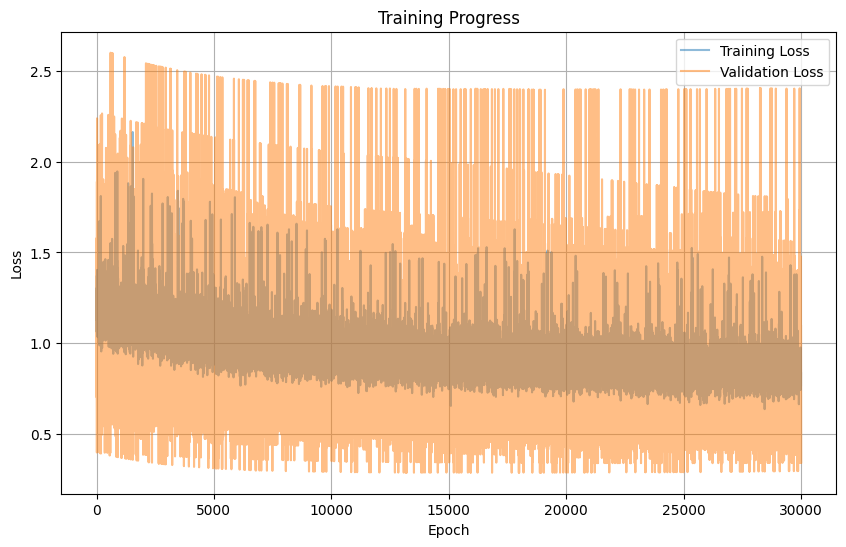

In [50]:
# Plot training progress
trainer.plot_losses()

In [51]:
# Example prediction
x_test = torch.FloatTensor(val_data[0])
x_pred = trainer.predict(x_test)
print(f"Input: {x_test}")
print(f"Predicted next state: {x_pred}")
print(f"Actual next state: {val_data[0][1]}")

# Multi-step prediction
multi_pred = trainer.multi_step_prediction(x_test, n_steps=10)
print(f"Multi-step predictions shape: {multi_pred.shape}")

Input: tensor([[-9.1693e-01, -1.6747e+00, -1.6318e-01,  ...,  3.7621e-01,
         -1.9753e-01,  9.8332e-01],
        [-9.0187e-01, -1.1863e+00,  1.2027e+00,  ..., -2.3403e-01,
          1.5328e-01,  2.1492e-01],
        [-1.3023e-01, -6.1498e-01,  1.7511e+00,  ...,  2.3190e-01,
         -2.0104e+00, -2.5762e-01],
        ...,
        [-4.5359e-01, -6.6725e-01,  1.1141e+00,  ..., -4.6999e-02,
         -1.1945e+00,  6.0498e-01],
        [ 3.3233e-01, -5.9733e-01,  2.5067e+00,  ...,  2.0793e-03,
         -1.5669e+00, -1.6630e-01],
        [-1.7587e-02,  5.1076e-03,  2.4940e+00,  ..., -4.1350e-01,
         -3.5197e-01, -1.9798e+00]])
Predicted next state: tensor([[-0.4813, -0.9690, -0.1535,  ...,  0.3843, -0.2170,  1.0579],
        [-0.2725, -0.6949,  0.4334,  ..., -0.1271, -0.4258, -0.0129],
        [ 0.1028, -0.5539,  0.9482,  ...,  0.1195, -1.4835,  0.0695],
        ...,
        [ 0.0048, -0.2712,  0.5434,  ..., -0.1145, -0.8161,  0.3663],
        [ 0.3442, -0.4242,  1.7149,  ..., -0.0